<a href="https://colab.research.google.com/github/alegouvea75/Projeto-Avaliativo-final-Modulo1/blob/main/Projeto_Avaliativo_semana_14.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

#---Projeto Avaliativo final---
##Importando as bibliotecas
##Data set: App de vendas previsão dos clientes que estão abandonando a plataforma.Prever se beneficio para manter cliente e valido financeiramente.

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
from imblearn.over_sampling import SMOTE
from sklearn.tree import DecisionTreeClassifier
from sklearn.neighbors import KNeighborsClassifier

# Configuração estética  dos gráficos
sns.set_theme(style="whitegrid")
plt.rcParams['figure.figsize'] = [10, 6]

#---Leitura dos dados cvs---
##Importando gdown para baixar o arquivo do Google Drive.
##Extrair a ID e lê o arquivo.

In [2]:
import gdown
url_base = 'https://drive.google.com/file/d/1Gcdv7zg4BDquToRBdRwIDksHicJPO0dd/view?usp=sharing'
output_filename = 'ecommerce_churn.csv'
gdown.download(url_base, output_filename, quiet=False, fuzzy=True)
df = pd.read_csv(output_filename)

Downloading...
From: https://drive.google.com/uc?id=1Gcdv7zg4BDquToRBdRwIDksHicJPO0dd
To: /content/ecommerce_churn.csv
100%|██████████| 482k/482k [00:00<00:00, 100MB/s]


#---1 Análise Exploratória de Dados (EDA)---
##Conhecer os dados colunas, linhas e estatiticas. O head da base.



In [3]:
print(f"\n1. Dimensões do Dataset: {df.shape[0]} linhas e {df.shape[1]} colunas.")

print("\n2. Visualizando a estrutura inicial dos dados:")
display(df.head(5))

print("\n3. Resumo Estatístico das Variáveis Numéricas:")
display(df.describe())


1. Dimensões do Dataset: 5630 linhas e 20 colunas.

2. Visualizando a estrutura inicial dos dados:


,CustomerID,Churn,Tenure,PreferredLoginDevice,CityTier,WarehouseToHome,PreferredPaymentMode,Gender,HourSpendOnApp,NumberOfDeviceRegistered,PreferedOrderCat,SatisfactionScore,MaritalStatus,NumberOfAddress,Complain,OrderAmountHikeFromlastYear,CouponUsed,OrderCount,DaySinceLastOrder,CashbackAmount
0,50001,1,4.0,Mobile Phone,3,6.0,Debit Card,Female,3.0,3,Laptop & Accessory,2,Single,9,1,11.0,1.0,1.0,5.0,160
1,50002,1,NaN,Phone,1,8.0,UPI,Male,3.0,4,Mobile,3,Single,7,1,15.0,0.0,1.0,0.0,121
2,50003,1,NaN,Phone,1,30.0,Debit Card,Male,2.0,4,Mobile,3,Single,6,1,14.0,0.0,1.0,3.0,120
3,50004,1,0.0,Phone,3,15.0,Debit Card,Male,2.0,4,Laptop & Accessory,5,Single,8,0,23.0,0.0,1.0,3.0,134
4,50005,1,0.0,Phone,1,12.0,CC,Male,NaN,3,Mobile,5,Single,3,0,11.0,1.0,1.0,3.0,130



3. Resumo Estatístico das Variáveis Numéricas:


,CustomerID,Churn,Tenure,CityTier,WarehouseToHome,HourSpendOnApp,NumberOfDeviceRegistered,SatisfactionScore,NumberOfAddress,Complain,OrderAmountHikeFromlastYear,CouponUsed,OrderCount,DaySinceLastOrder,CashbackAmount
count,5630.000000,5630.000000,5366.000000,5630.000000,5379.000000,5375.000000,5630.000000,5630.000000,5630.000000,5630.000000,5365.000000,5374.000000,5372.000000,5323.000000,5630.000000
mean,52815.500000,0.168384,10.189899,1.654707,15.639896,2.931535,3.688988,3.066785,4.214032,0.284902,15.707922,1.751023,3.008004,4.543491,177.221492
std,1625.385339,0.374240,8.557241,0.915389,8.531475,0.721926,1.023999,1.380194,2.583586,0.451408,3.675485,1.894621,2.939680,3.654433,49.193869
min,50001.000000,0.000000,0.000000,1.000000,5.000000,0.000000,1.000000,1.000000,1.000000,0.000000,11.000000,0.000000,1.000000,0.000000,0.000000
25%,51408.250000,0.000000,2.000000,1.000000,9.000000,2.000000,3.000000,2.000000,2.000000,0.000000,13.000000,1.000000,1.000000,2.000000,146.000000
50%,52815.500000,0.000000,9.000000,1.000000,14.000000,3.000000,4.000000,3.000000,3.000000,0.000000,15.000000,1.000000,2.000000,3.000000,163.000000
75%,54222.750000,0.000000,16.000000,3.000000,20.000000,3.000000,4.000000,4.000000,6.000000,1.000000,18.000000,2.000000,3.000000,7.000000,196.000000
max,55630.000000,1.000000,61.000000,3.000000,127.000000,5.000000,6.000000,5.000000,22.000000,1.000000,26.000000,16.000000,16.000000,46.000000,325.000000


##Parte visual de garficos


Text(0.5, 1.0, 'Distribuição: Dias desde o último pedido')

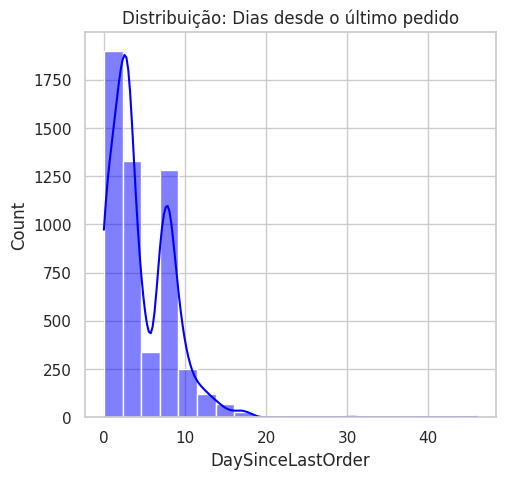

In [4]:
#Gráfico 1 histograma para visualizar a distribuição dos valores.
#---visualisação tamanho padrão---
#ciclo de atividade dos clientes.
plt.figure(figsize=(18, 5))

#Gráfico
plt.subplot(1, 3, 1)
sns.histplot(df['DaySinceLastOrder'], bins=20, kde=True, color='blue')
plt.title('Distribuição: Dias desde o último pedido')


Text(0.5, 1.0, 'Desbalanceamento da Variável Alvo (Churn)')

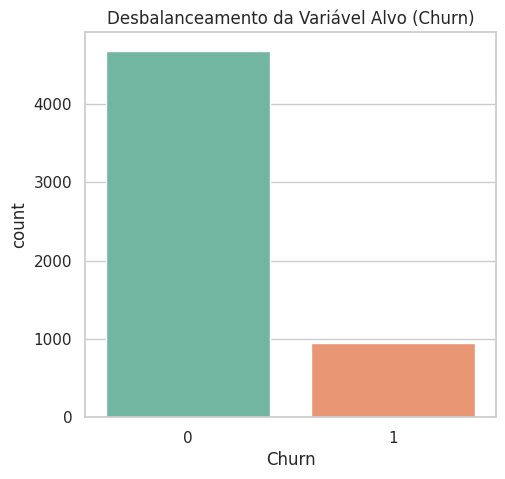

In [5]:
#Gráfico 2 Desbalanceamento. Barras.
#---visualisação tamanho padrão---
#Mostar os cliente ativos (0) e churm (1)
plt.figure(figsize=(18, 5))

#Gráfico
plt.subplot(1, 3, 2)
sns.countplot(x='Churn', data=df, hue='Churn', palette='Set2', legend=False)
plt.title('Desbalanceamento da Variável Alvo (Churn)')


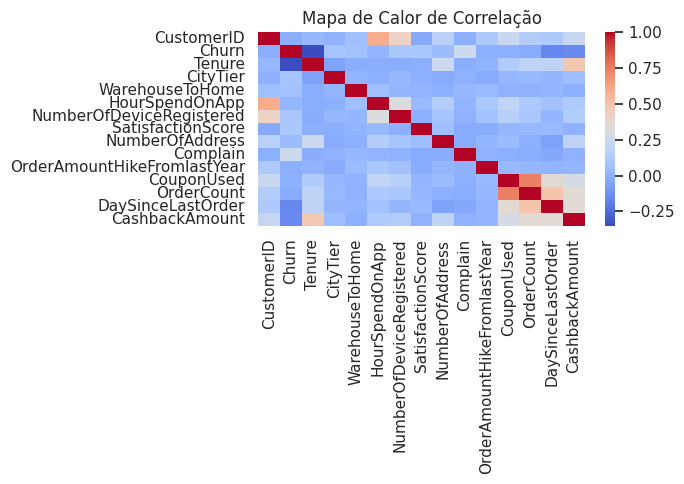

In [6]:
#Gráfico 3 mapa de calor.
#---visualisação tamanho padrão---
plt.figure(figsize=(18, 5))
plt.subplot(1, 3, 3)
colunas_numericas = df.select_dtypes(include=['int64', 'float64']).columns
sns.heatmap(df[colunas_numericas].corr(), annot=False, cmap='coolwarm')
plt.title('Mapa de Calor de Correlação')
plt.tight_layout()
plt.show()


##Tomada de Decisão
###Como podemos ver no primeiro gráfico (histograma), mostra que as pessoas voltam a comprar entre as 2 primeiras semanas estando ativos no App. No Gráfico 2 confirma um grande Desbalanceamento mostra que a grande maioria do clientes esta ativa. Gráfico 3 mostra que o uso de cupom mantem os clientes, sendo uma boa estrategia manter quem esta no app usando alguns beneficios tem menos custo de conseguir novos clientes.


#---2 Tratamento e limpeza de dados---

In [7]:
# 1 Remoção de linhas Duplicadas e CustomerID
df = df.drop_duplicates()
# Verifica se 'CustomerID' existe antes de tentar dropar
if 'CustomerID' in df.columns:
    df = df.drop(columns=['CustomerID'], errors='ignore')

# Define as colunas numéricas e categóricas após as remoções iniciais
colunas_num = df.select_dtypes(include=['int64', 'float64']).columns
colunas_cat = df.select_dtypes(include=['object']).columns

# 2. Tratamento de Valores Nulos
# 1. Preenche os valores nulos das colunas numéricas com a mediana
# e das colunas categóricas com a moda (valor mais frequente)
df = df.fillna({
    # Colunas Numéricas (Preenchendo com Mediana)
    'Churn': df['Churn'].median(),
    'Tenure': df['Tenure'].median(),
    'CityTier': df['CityTier'].median(),
    'WarehouseToHome': df['WarehouseToHome'].median(),
    'HourSpendOnApp': df['HourSpendOnApp'].median(),
    'NumberOfDeviceRegistered': df['NumberOfDeviceRegistered'].median(),
    'SatisfactionScore': df['SatisfactionScore'].median(),
    'NumberOfAddress': df['NumberOfAddress'].median(),
    'Complain': df['Complain'].median(),
    'OrderAmountHikeFromlastYear': df['OrderAmountHikeFromlastYear'].median(),
    'CouponUsed': df['CouponUsed'].median(),
    'OrderCount': df['OrderCount'].median(),
    'DaySinceLastOrder': df['DaySinceLastOrder'].median(),
    'CashbackAmount': df['CashbackAmount'].median(),

    # Colunas Categóricas (Preenchendo com a Moda)
    'PreferredLoginDevice': df['PreferredLoginDevice'].mode()[0],
    'PreferredPaymentMode': df['PreferredPaymentMode'].mode()[0],
    'Gender': df['Gender'].mode()[0],
    'PreferedOrderCat': df['PreferedOrderCat'].mode()[0],
    'MaritalStatus': df['MaritalStatus'].mode()[0]
})
print("\n2. Contagem de Valores Nulos (NaN) DEPOIS do tratamento: Tudo zerado!")
print(df.isna().sum()[df.isna().sum() > 0])

# 2. Remove qualquer linha com nulos que possa ter restado em outras colunas
df = df.dropna()

# remoção de linhas duplicadas
linhas_antes = df.shape[0]
print(f'Quantidade de linhas apos remoção de nulos',linhas_antes)
print(df[df.duplicated(keep=False)])
df = df.drop_duplicates()
print(f"\n3. Remoção de Duplicatas: {linhas_antes - df.shape[0]} linhas "
      f"clonadas eliminadas de forma segura.")

# Verifique se ainda restam valores nulos no seu DataFrame
print("\nValores nulos restantes:")
print(df.isnull().sum())

# 3. Tratamento de Outliers
colunas_para_outliers = [c for c in colunas_num if c != 'Churn' and c != 'CustomerID']

for col in colunas_para_outliers:
    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)
    IQR = Q3 - Q1
    limite_inferior = Q1 - 1.5 * IQR
    limite_superior = Q3 + 1.5 * IQR

    # Aplica o clipping: o que for menor que o mínimo vira o mínimo, o que for maior vira o máximo
    df[col] = df[col].clip(lower=limite_inferior, upper=limite_superior)


2. Contagem de Valores Nulos (NaN) DEPOIS do tratamento: Tudo zerado!
Series([], dtype: int64)
Quantidade de linhas apos remoção de nulos 5630
      Churn  Tenure PreferredLoginDevice  CityTier  WarehouseToHome  \
1         1     9.0                Phone         1              8.0   
2         1     9.0                Phone         1             30.0   
11        1    11.0         Mobile Phone         1              6.0   
18        1     0.0             Computer         1             13.0   
25        1     0.0                Phone         1             15.0   
...     ...     ...                  ...       ...              ...   
5611      0    12.0         Mobile Phone         3             17.0   
5613      0    10.0         Mobile Phone         3             18.0   
5620      0     3.0         Mobile Phone         1             35.0   
5625      0    10.0             Computer         1             30.0   
5628      0    23.0             Computer         3              9.0   

   

## Mostrar Valores Nulos Antes da limpeza e confirmar que não tem depois de limpos.



In [8]:
import pandas as pd

# Carrega o DataFrame original novamente para comparar os nulos antes do tratamento
df_original = pd.read_csv(output_filename)

print("Valores nulos ANTES do tratamento de limpeza:")
print(df_original.isnull().sum()[df_original.isnull().sum() > 0])

Valores nulos ANTES do tratamento de limpeza:
Tenure                         264
WarehouseToHome                251
HourSpendOnApp                 255
OrderAmountHikeFromlastYear    265
CouponUsed                     256
OrderCount                     258
DaySinceLastOrder              307
dtype: int64


In [9]:
print("\nValores nulos DEPOIS do tratamento de limpeza:")
print(df.isnull().sum()[df.isnull().sum() > 0])


Valores nulos DEPOIS do tratamento de limpeza:
Series([], dtype: int64)


#---3 Feature Engineering---

In [10]:
# Criação da nova coluna exigida pelo projeto: cashback_por_pedido = Cashbackamount/OrderCont
df['cashback_por_pedido'] = df['CashbackAmount'] / (df['OrderCount'] + 0.0001)

print("Nova coluna criada com sucesso. Amostra:")
display(df[['CashbackAmount', 'OrderCount', 'cashback_por_pedido']].head())



Nova coluna criada com sucesso. Amostra:


,CashbackAmount,OrderCount,cashback_por_pedido
0,160,1.0,159.984002
1,121,1.0,120.987901
2,120,1.0,119.988001
3,134,1.0,133.986601
4,130,1.0,129.987001


#---4 Separação, Balanceamento e Escalonamento Seguro---
##Vamos Criar dados da classe com menos dados permitindo que o modelo aprenda de forma justa a reconhecer ambos os cenários. Para não ter uma falsa acurácia com os dados majoritário já que estavam desbalanciados.

In [11]:
# 1. Encoding usando One-Hot Encoding
# evitar multicolinearidade
df_encoded = pd.get_dummies(df, drop_first=True)

# 2. Split de Dados (X e y)
X = df_encoded.drop('Churn', axis=1)
y = df_encoded['Churn']

# Stratify=y preserva a proporção das classes
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.20, stratify=y, random_state=42)

# 3. Balanceamento (SOMENTE NO TREINO para evitar vazamento de dados)
smote = SMOTE(random_state=42)
X_train_bal, y_train_bal = smote.fit_resample(X_train, y_train)

# 4. Escalonamento Seguro (EXCLUSIVAMENTE NAS VARIÁVEIS CONTÍNUAS para o KNN)
# Lista com o nome das colunas que são números contínuos (substitua se necessário)
colunas_continuas = ['Tenure', 'WarehouseToHome', 'HourSpendOnApp', 'NumberOfDeviceRegistered',
                     'SatisfactionScore', 'NumberOfAddress', 'Complain',
                     'OrderAmountHikeFromlastYear', 'CouponUsed', 'OrderCount',
                     'DaySinceLastOrder', 'CashbackAmount']

scaler = StandardScaler()
# Criando cópias para não alterar os dados originais balanceados que irão para a Árvore
X_train_bal_scaled = X_train_bal.copy()
X_test_scaled = X_test.copy()

# Fit_transform no treino e transform no teste (APENAS nas contínuas)
X_train_bal_scaled[colunas_continuas] = scaler.fit_transform(X_train_bal[colunas_continuas])
X_test_scaled[colunas_continuas] = scaler.transform(X_test[colunas_continuas])

print("Tamanho do Treino antes do SMOTE:", X_train.shape)
print("Tamanho do Treino após o SMOTE:", X_train_bal.shape)

Tamanho do Treino antes do SMOTE: (4057, 30)
Tamanho do Treino após o SMOTE: (6768, 30)


#---5 Modelagem e validação---
##Diagnostico de overfitting
###Comparando com multiplos treinos o KNN e a Árvore de decisão.
####Demostrando tabela com métricas de ambas as bases.
##### O modelo que evitou o overfitting e garantiu o resultado mais equilibrado foi a Árvore de Decisão com Profundidade = 5. Treino: 86,10% e teste: 86,11% esta estável em relação ao que ele aprendeu e uma boa metrica para ver que o modelo não decorou.

In [12]:
from sklearn.metrics import accuracy_score
import matplotlib.pyplot as plt

# Otimização do KNN
k_values = [3, 5, 7, 9]
for k in k_values:
    knn = KNeighborsClassifier(n_neighbors=k)
    knn.fit(X_train_bal_scaled, y_train_bal)

    acc_train = accuracy_score(y_train_bal, knn.predict(X_train_bal_scaled))
    acc_test = accuracy_score(y_test, knn.predict(X_test_scaled))
    print(f"KNN (K={k}) -> Acurácia Treino: {acc_train:.4f} | Teste: {acc_test:.4f}")

# Otimização da Árvore de Decisão
print("\n--- Iniciando Fase 5: Otimização da Árvore de Decisão ---")
# Testando 4 cenários de profundidade máxima
depth_values = [3, 5, 7, None]
for depth in depth_values:
    tree = DecisionTreeClassifier(max_depth=depth, random_state=42)
    tree.fit(X_train_bal, y_train_bal) # Sem dados escalonados

    acc_train = accuracy_score(y_train_bal, tree.predict(X_train_bal))
    acc_test = accuracy_score(y_test, tree.predict(X_test))
    print(f"Árvore (Profundidade={depth}) -> Acurácia Treino: {acc_train:.4f} | Teste: {acc_test:.4f}")

KNN (K=3) -> Acurácia Treino: 0.9737 | Teste: 0.8394
KNN (K=5) -> Acurácia Treino: 0.9314 | Teste: 0.8010
KNN (K=7) -> Acurácia Treino: 0.9116 | Teste: 0.7852
KNN (K=9) -> Acurácia Treino: 0.8945 | Teste: 0.7862

--- Iniciando Fase 5: Otimização da Árvore de Decisão ---
Árvore (Profundidade=3) -> Acurácia Treino: 0.8008 | Teste: 0.8335
Árvore (Profundidade=5) -> Acurácia Treino: 0.8610 | Teste: 0.8611
Árvore (Profundidade=7) -> Acurácia Treino: 0.8969 | Teste: 0.8640
Árvore (Profundidade=None) -> Acurácia Treino: 1.0000 | Teste: 0.9143


#---6 Avaliação e veridito do Negócio---
##Treinando os melhores modelos escolhidos para produção



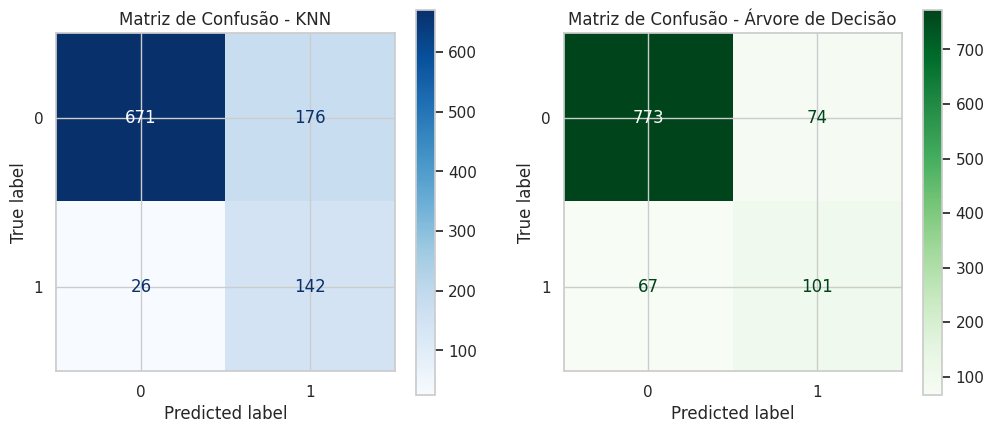

--- Classification Report (Melhor KNN) ---
              precision    recall  f1-score   support

           0       0.96      0.79      0.87       847
           1       0.45      0.85      0.58       168

    accuracy                           0.80      1015
   macro avg       0.70      0.82      0.73      1015
weighted avg       0.88      0.80      0.82      1015


--- Classification Report (Melhor Árvore) ---
              precision    recall  f1-score   support

           0       0.92      0.91      0.92       847
           1       0.58      0.60      0.59       168

    accuracy                           0.86      1015
   macro avg       0.75      0.76      0.75      1015
weighted avg       0.86      0.86      0.86      1015



<Figure size 1000x600 with 0 Axes>

In [13]:
from sklearn.metrics import classification_report, ConfusionMatrixDisplay

# Treinando os melhores modelos
best_knn = KNeighborsClassifier(n_neighbors=5)
best_knn.fit(X_train_bal_scaled, y_train_bal)
y_pred_knn = best_knn.predict(X_test_scaled)

best_tree = DecisionTreeClassifier(max_depth=5, random_state=42)
best_tree.fit(X_train_bal, y_train_bal)
y_pred_tree = best_tree.predict(X_test)

# Matrizes e Relatórios
fig, ax = plt.subplots(1, 2, figsize=(12, 5))

ConfusionMatrixDisplay.from_predictions(y_test, y_pred_knn, ax=ax[0], cmap='Blues')
ax[0].set_title("Matriz de Confusão - KNN")

ConfusionMatrixDisplay.from_predictions(y_test, y_pred_tree, ax=ax[1], cmap='Greens')
ax[1].set_title("Matriz de Confusão - Árvore de Decisão")

plt.show()

print("--- Classification Report (Melhor KNN) ---")
print(classification_report(y_test, y_pred_knn))

print("\n--- Classification Report (Melhor Árvore) ---")
print(classification_report(y_test, y_pred_tree))

plt.tight_layout()
plt.show();

#--Avaliação e veredito---
###Analisando o quadro o melhor modelo a ser usar e o KNN Recall de 0,85 falso positivo Churn 1. Nenhuma ML e 100% assertiva, tentamos prever a melhor ação que uma empresa deve fazer para ter lucro. Neste caso o uso do cupom entre desconto fidelidade de 10% ou 15% a empresa consegue ter uma ação com o cliente ainda no seu App. Focado na classe 1 o Churn, o modelo prevê que vai abandonar, mas e uma hipótese ele ainda compra, então vamos acreditar na previsão que este cliente tem grande chance de sair do app e ter uma ação de desconto com o intuito de mantê-lo. Sendo que a parte administrativa pode até ajustar futuramente no seu custo uma parte do valor usado nos cupons. Se ela não tomar nenhuma decisão acreditando que o cliente e fiel e não vai sair do App, futuramente pode ser muito mais custoso do que os 10 ou 15% usado na previsão. Um Exemplo simples; pensamos assim se o cliente sai, a empresa perde toda a lucratividade que teria com ele, diminui a receita, gasta com marketing na recuperação e ainda talvez tenha que ser mais atrativo que 10 ou 15% no seu cupom para recuperar um cliente antigo. Lembrando que está e uma estratégia que estamos focando somente para aqueles que a ML prevê que pode abandonar. Nada impede de futuramente usarmos outro tipo de estratégia para a classe 0, mas no momento o nosso objetivo e reter o possível Churn.
